<a href="https://colab.research.google.com/github/msondhi/3253_097-Machine-Learning/blob/develop/DL_Program_01ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building an Image Classifier Using the Sequential API

Using Keras to load the dataset

In [4]:
import tensorflow as tf
fashion_mnist =tf.keras.datasets.fashion_mnist.load_data()
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist
X_train,y_train= X_train_full[:-5000],y_train_full[:-5000]
X_valid,y_valid=X_train_full[-5000:],y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
X_train.shape

(55000, 28, 28)

In [6]:
y_train.shape

(55000,)

In [7]:
print('Original X_train_full (first image, top-left pixel values):')
display(X_train_full[0, :5, :5])

print('\nProcessed X_train (first image, top-left pixel values after scaling):')
display(X_train[0, :5, :5])

Original X_train_full (first image, top-left pixel values):


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint8)


Processed X_train (first image, top-left pixel values after scaling):


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint8)

In [8]:
print('Original y_train_full (first 5 labels):')
display(y_train_full[:5])

print('\nProcessed y_train (first 5 labels):')
display(y_train[:5])

Original y_train_full (first 5 labels):


array([9, 0, 0, 3, 0], dtype=uint8)


Processed y_train (first 5 labels):


array([9, 0, 0, 3, 0], dtype=uint8)

In [9]:
X_train,X_valid,X_test=X_train/255,X_valid/255,X_test/255

In [10]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress",
"Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [11]:
class_names[y_train[2]]

'T-shirt/top'

Creating the model using the sequential API

In [12]:
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [15]:
hidden1 = model.layers[1]
hidden1.name

'dense'

In [16]:
weights,biases=hidden1.get_weights()
weights

array([[-0.07296411,  0.00779635,  0.01715405, ...,  0.00483496,
         0.05830137, -0.03513088],
       [ 0.04106299, -0.05506192, -0.01591079, ..., -0.04959273,
        -0.02847967,  0.05319764],
       [ 0.06835061,  0.07036252, -0.00885252, ..., -0.03902278,
         0.07042466, -0.06236713],
       ...,
       [ 0.05171283,  0.06412256, -0.05293731, ..., -0.0593622 ,
        -0.0569693 , -0.0731995 ],
       [ 0.00381284,  0.01183003, -0.03113513, ...,  0.05081277,
         0.06433062, -0.04759309],
       [-0.06286721,  0.00023019, -0.0017892 , ...,  0.0203857 ,
        -0.00608903, -0.0176575 ]], dtype=float32)

In [17]:
weights.shape


(784, 300)

In [18]:
biases.shape

(300,)

In [19]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Compiling the model

In [20]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

Training and evaluating the model

In [21]:
history = model.fit(X_train, y_train, epochs=30,validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7638 - loss: 0.7148 - val_accuracy: 0.8218 - val_loss: 0.5113
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8330 - loss: 0.4834 - val_accuracy: 0.8330 - val_loss: 0.4609
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8479 - loss: 0.4378 - val_accuracy: 0.8422 - val_loss: 0.4388
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8563 - loss: 0.4107 - val_accuracy: 0.8468 - val_loss: 0.4220
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8629 - loss: 0.3908 - val_accuracy: 0.8520 - val_loss: 0.4088
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8681 - loss: 0.3749 - val_accuracy: 0.8548 - val_loss: 0.3987
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8722 - loss: 0.3615 - val_accuracy: 0.8588 - val_loss: 0.3888
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8763 - loss: 0.3498 - 

In [22]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

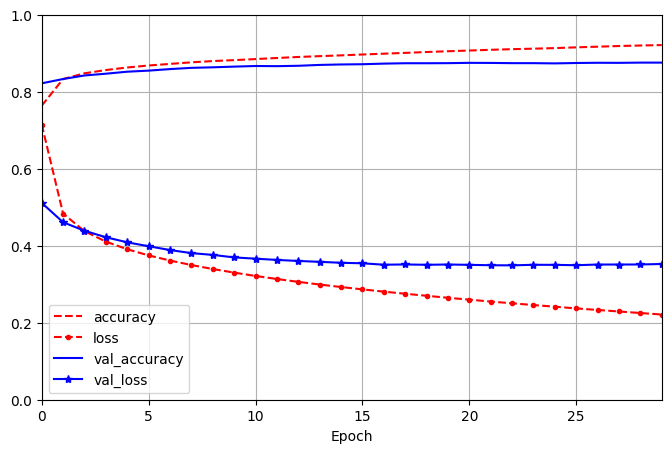

In [23]:
import matplotlib.pyplot as plt
import pandas as pd


pd.DataFrame(history.history).plot(
figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True,
xlabel="Epoch",
style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [24]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8712 - loss: 0.3736


[0.3736265003681183, 0.8712000250816345]

In [25]:
X_new=X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.28, 0.  , 0.  , 0.  , 0.71],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [26]:
import numpy as np
y_pred = y_proba.argmax(axis=-1)
y_pred

array([9, 2, 1])